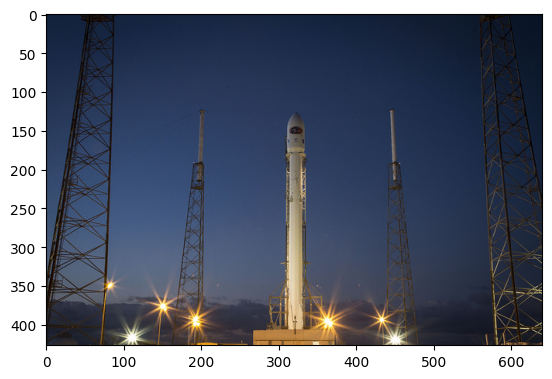

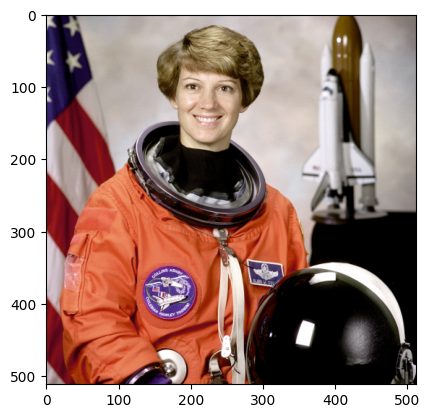

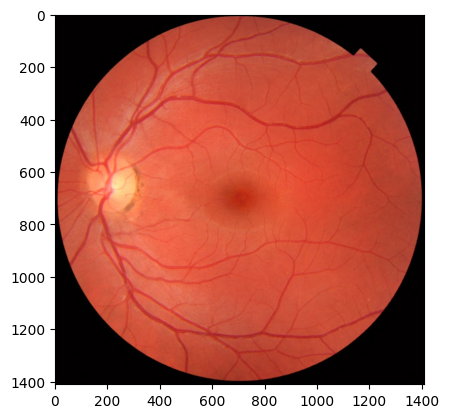

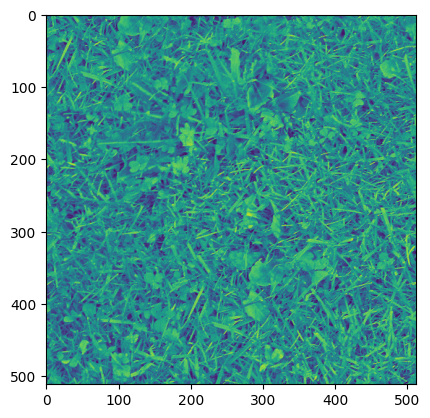

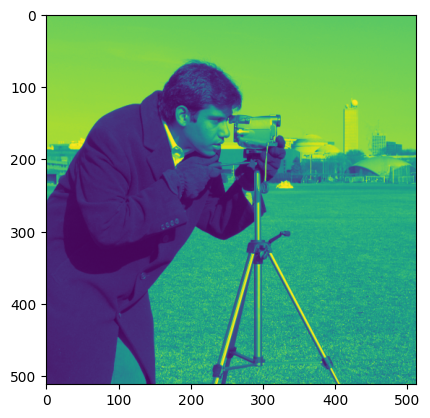

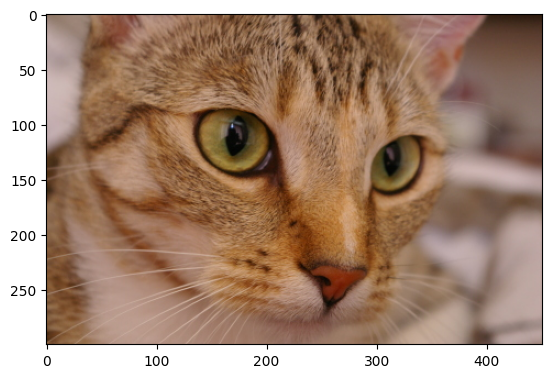

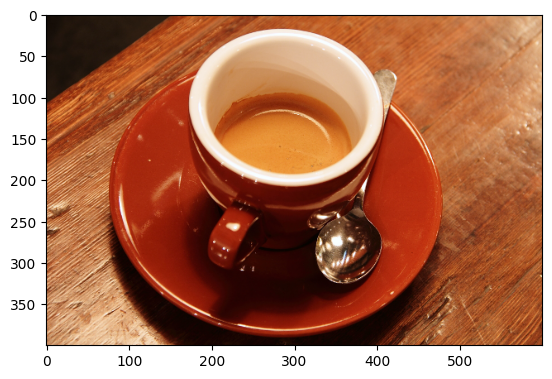

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, util
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

img_list = ['rocket', 'astronaut', 'retina', 'grass', 'camera', 'cat', 'coffee']
for img in img_list:
    plt.imshow(eval(f'data.{img}()'))
    plt.show()

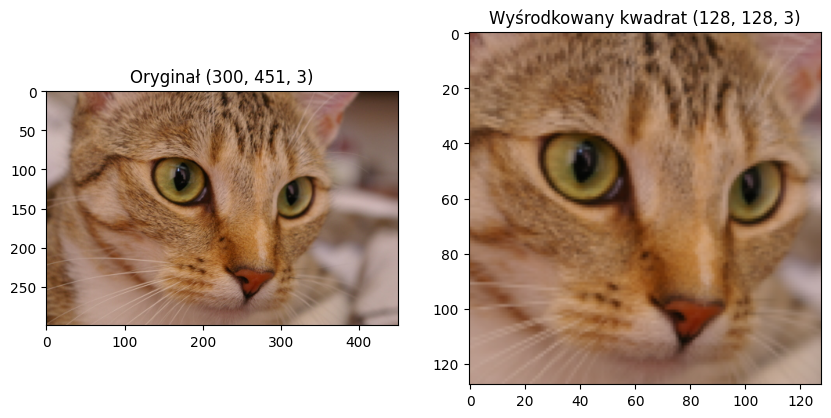

In [8]:
cat_image = data.chelsea()

wysokosc, szerokosc, _ = cat_image.shape

min_bok = min(wysokosc, szerokosc)
start_y = wysokosc // 2 - min_bok // 2
start_x = szerokosc // 2 - min_bok // 2

kwadratowy_kot = cat_image[start_y:start_y+min_bok, start_x:start_x+min_bok]

kot_128 = transform.resize(kwadratowy_kot, (128, 128))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cat_image)
ax[0].set_title(f'Oryginał {cat_image.shape}')
ax[1].imshow(kot_128)
ax[1].set_title(f'Wyśrodkowany kwadrat {kot_128.shape}')
plt.show()

image_resized_example = kot_128

In [9]:
image_gray = color.rgb2gray(image_resized_example)

image_flattened = image_gray.flatten()

print("Kształt po konwersji do szarości:", image_gray.shape)
print("Kształt spłaszczonego wektora:  ", image_flattened.shape)


Kształt po konwersji do szarości: (128, 128)
Kształt spłaszczonego wektora:   (16384,)


In [10]:
wektor_2d = image_flattened.reshape(1, -1)

scaler = StandardScaler()

wektor_standaryzowany = scaler.fit_transform(wektor_2d)

print(f"Srednia przed: {wektor_2d.mean():.4f}")
print(f"Średnia po (Z-Score): {wektor_standaryzowany.mean():.4f}")

print(f"\nOdchylenie stand. przed: {wektor_2d.std():.4f}")
print(f"Odchylenie stand. po:    {wektor_standaryzowany.std():.4f}")

Srednia przed: 0.4515
Średnia po (Z-Score): 0.0000

Odchylenie stand. przed: 0.1180
Odchylenie stand. po:    0.0000


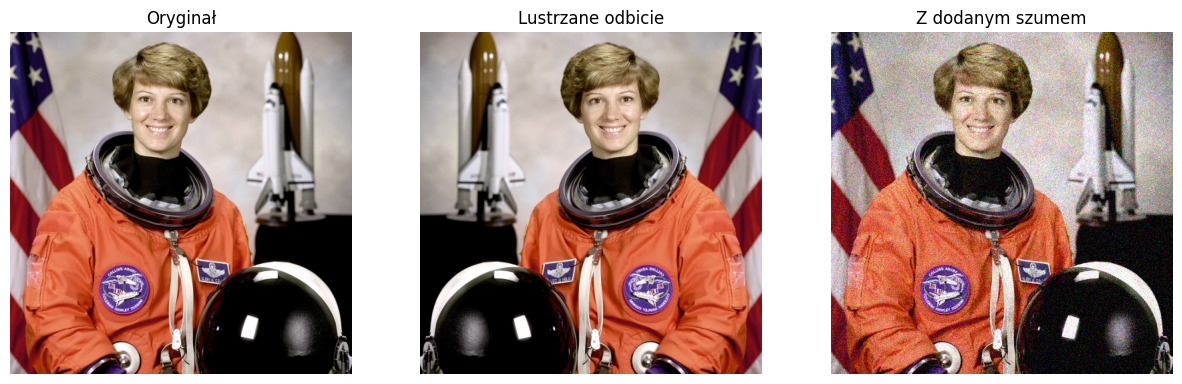

In [11]:
astronaut = data.astronaut()

astronaut_flipped = np.fliplr(astronaut)

astronaut_noisy = util.random_noise(astronaut)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(astronaut)
ax[0].set_title('Oryginał')
ax[0].axis('off')

ax[1].imshow(astronaut_flipped)
ax[1].set_title('Lustrzane odbicie')
ax[1].axis('off')

ax[2].imshow(astronaut_noisy)
ax[2].set_title('Z dodanym szumem')
ax[2].axis('off')

plt.show()

Oryginalna liczba cech: 64
Zachowana liczba komponentów: 21


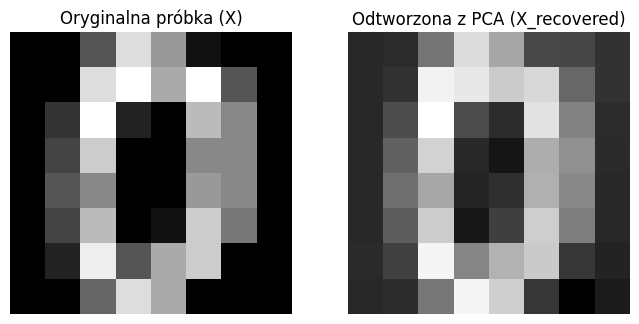

In [12]:
digits = load_digits()
X = digits.data

pca = PCA(n_components=0.90)

X_pca = pca.fit_transform(X)

print(f"Oryginalna liczba cech: {X.shape[1]}")
print(f"Zachowana liczba komponentów: {pca.n_components_}")

X_recovered = pca.inverse_transform(X_pca)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(X[0].reshape(8, 8), cmap='gray')
ax[0].set_title('Oryginalna próbka (X)')
ax[0].axis('off')

ax[1].imshow(X_recovered[0].reshape(8, 8), cmap='gray')
ax[1].set_title('Odtworzona z PCA (X_recovered)')
ax[1].axis('off')

plt.show()

In [14]:
import random
import os

def flip_or_not_to_flip(img, prob=0.5):
    if random.random() < prob:
        return np.fliplr(img)
    return img

def gray_or_not_gray(img, prob=0.5):
    if random.random() < prob:
        if len(img.shape) == 3:
            return color.rgb2gray(img)
    return img

def preprocess_images(img_list, target_size=(128, 128), output_dir="przetworzone"):
    os.makedirs(output_dir, exist_ok=True)

    for img_name in img_list:
        try:
            zdjecie_obj = getattr(data, img_name)
            img = zdjecie_obj()
        except AttributeError:
            print(f"Zdjecie '{img_name}' nie istnieje w bazie skimage.data. Pomijam.")
            continue

        wysokosc, szerokosc = img.shape[0], img.shape[1]

        if wysokosc != target_size[0] or szerokosc != target_size[1]:
            min_bok = min(wysokosc, szerokosc)
            y_s = wysokosc // 2 - min_bok // 2
            x_s = szerokosc // 2 - min_bok // 2
            img_cropped = img[y_s:y_s+min_bok, x_s:x_s+min_bok]

            img = transform.resize(img_cropped, target_size)

        img = flip_or_not_to_flip(img, prob=0.5)
        img = gray_or_not_gray(img, prob=0.5)

        sciezka_pliku = os.path.join(output_dir, f"{img_name}_processed.png")
        plt.imsave(sciezka_pliku, img, cmap='gray' if len(img.shape) == 2 else None)
        print(f"Zapisano zdjęcie pod ścieżką: {sciezka_pliku}")


img_list = ['rocket', 'astronaut', 'retina', 'grass', 'camera', 'cat', 'coffee']
preprocess_images(img_list, target_size=(200, 200), output_dir="moje_zmodyfikowane_zdjecia")

Zapisano zdjęcie pod ścieżką: moje_zmodyfikowane_zdjecia\rocket_processed.png
Zapisano zdjęcie pod ścieżką: moje_zmodyfikowane_zdjecia\astronaut_processed.png
Zapisano zdjęcie pod ścieżką: moje_zmodyfikowane_zdjecia\retina_processed.png
Zapisano zdjęcie pod ścieżką: moje_zmodyfikowane_zdjecia\grass_processed.png
Zapisano zdjęcie pod ścieżką: moje_zmodyfikowane_zdjecia\camera_processed.png
Zapisano zdjęcie pod ścieżką: moje_zmodyfikowane_zdjecia\cat_processed.png
Zapisano zdjęcie pod ścieżką: moje_zmodyfikowane_zdjecia\coffee_processed.png
